In [87]:
import numpy as np
import astropy.units as u
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from importlib import reload
from astropy.io import fits

from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle
import matplotlib.pyplot as plt

from scoob_llowfsc.math_module import xp, xcipy, ensure_np_array
from scoob_llowfsc import utils
from scoob_llowfsc import dm
from scoob_llowfsc import iefc_sim as iefc
import scoob_llowfsc.scoob_model as scoobm

inwfefname="example_wfe_data50.pkl"
wfe_data = utils.load_pickle('sim-data/'+inwfefname)

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(50, 50))

Oversampling > 2x suggested for reliable results in Fresnel propagation.


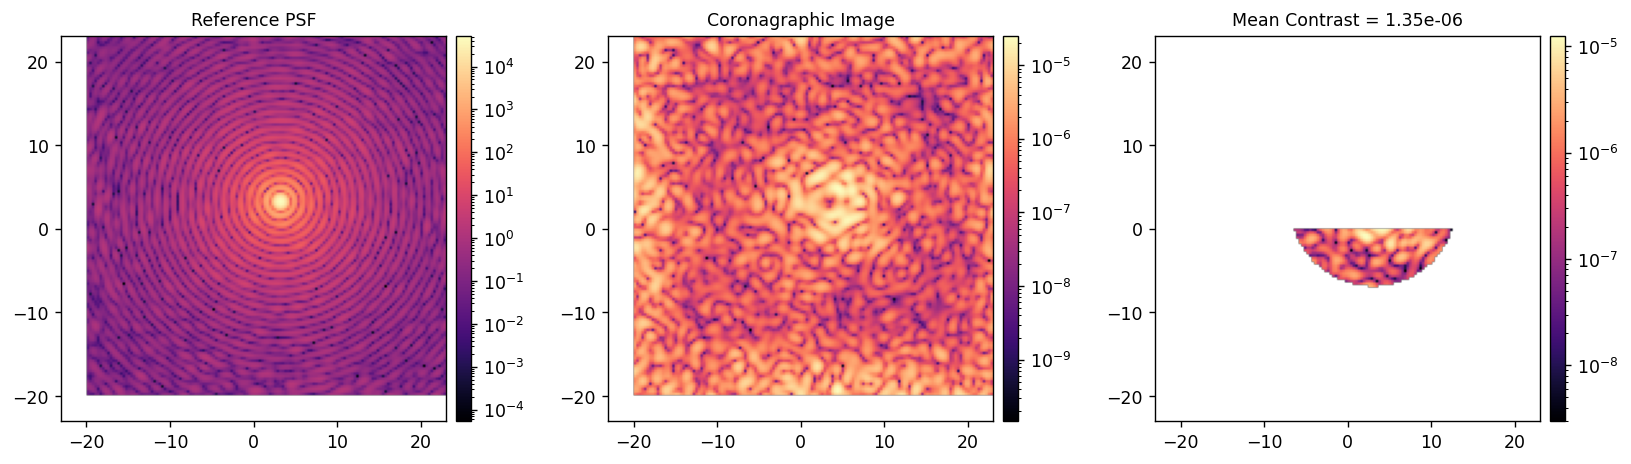

In [90]:
reload(scoobm)
reload(utils)
import copy

reload(scoobm)
Nact=50
scale=Nact/34
M = scoobm.single(Nact=Nact,
                         total_pupil_diam = 2.4, # assumed total telescope diameter
        fsm_beam_diam = 7.1e-3,
        dm_beam_diam = scale*9.1e-3, # as measured in the Fresnel model
        lyot_pupil_diam = scale*9.1e-3,
        lyot_diam = scale*8.6e-3,
        rls_diam = 25.4e-3,
        d_oap_ls = 150e-3,
        act_spacing = 300e-6)
Model2=copy.deepcopy(M)
Model3=copy.deepcopy(M)

M.ncamsci = 150
M.camsci_shear = (10, 10)

M.PREFPM_AMP = xp.asarray(wfe_data['PREFPM_AMP'])
M.PREFPM_OPD = xp.asarray(wfe_data['PREFPM_OPD'])

M.POSTFPM_AMP = xp.asarray(wfe_data['POSTFPM_AMP'])
M.POSTFPM_OPD = xp.asarray(wfe_data['POSTFPM_OPD'])

M.RLS_AMP = xp.asarray(wfe_data['RLS_AMP'])
M.RLS_OPD = xp.asarray(wfe_data['RLS_OPD'])

M.dm_ref = xp.asarray(wfe_data['DM_FLAT'])
M.reset_dm()

iwa = 3
owa = 10
# control_mask = utils.create_annular_focal_plane_mask(
control_mask = utils.create_annular_mask(
    M.ncamsci, 
    M.camsci_pxscl_lamD, 
    iwa, 
    owa,  
    edge=iwa,
    x_shift=10,
    y_shift=10,
    rotation=90,
)
# imshow1(control_mask, pxscl=M.camsci_pxscl_lamD)

M.use_vortex = 0
ref_psf = M.snap_camsci()
M.Imax_ref = xp.max(ref_psf)

M.use_vortex = 1
camsci_im0 = M.snap_camsci()
mean_contrast0 = xp.mean(camsci_im0[control_mask])

utils.imshow(
    [ref_psf, camsci_im0, camsci_im0*control_mask],
    titles=['Reference PSF', 'Coronagraphic Image', f'Mean Contrast = {mean_contrast0:.2e}'], 
    pxscls=3*[M.camsci_pxscl_lamDc],
    norms=[LogNorm(), LogNorm(), LogNorm()], 
)





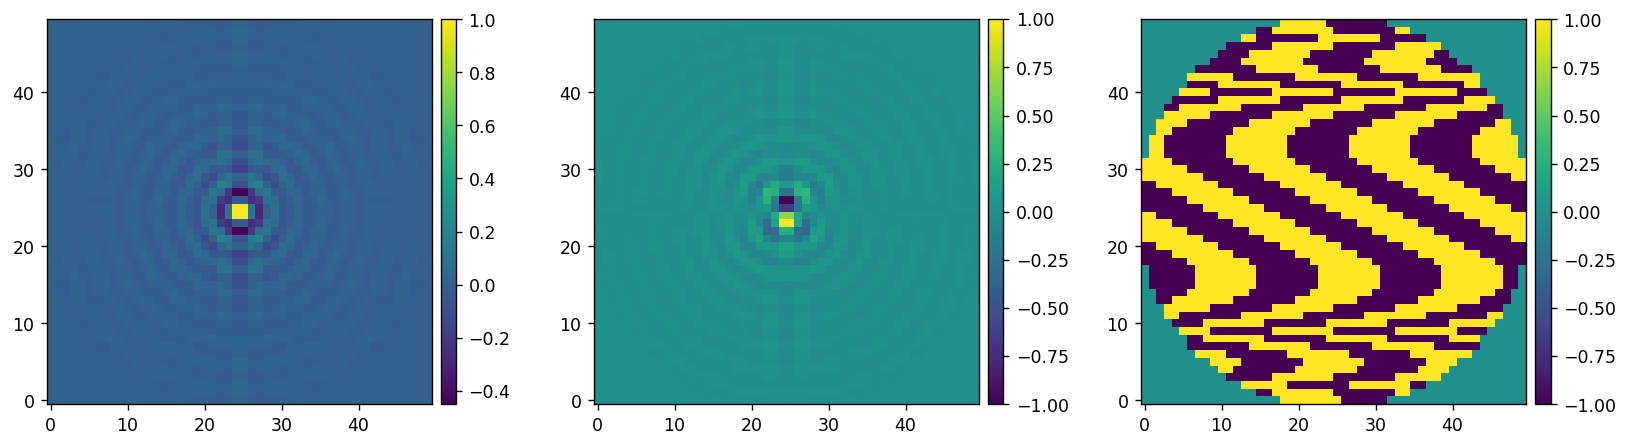

In [91]:
reload(utils)
reload(dm)
fourier_probes = dm.create_fourier_probes(
    M.dm_mask, 
    M.ncamsci, 
    M.camsci_pxscl_lamDc, 
    2, 
    15, 
    # iwa-1, 16, 
    rotation=90,
    use_weighting=True,
    nprobes=2,
)

calib_modes = dm.create_hadamard_modes(M.dm_mask)

utils.imshow([fourier_probes[0], fourier_probes[1], calib_modes[8]], cmaps=3*['viridis'])

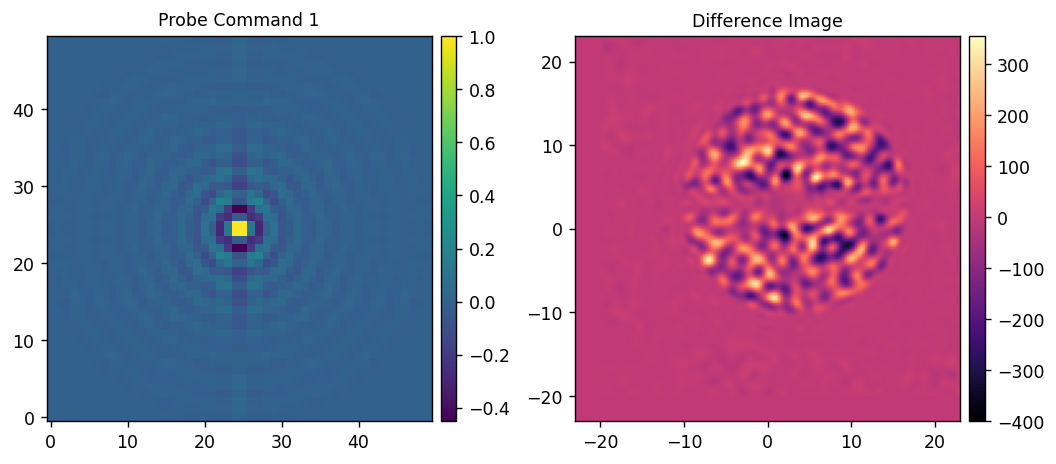

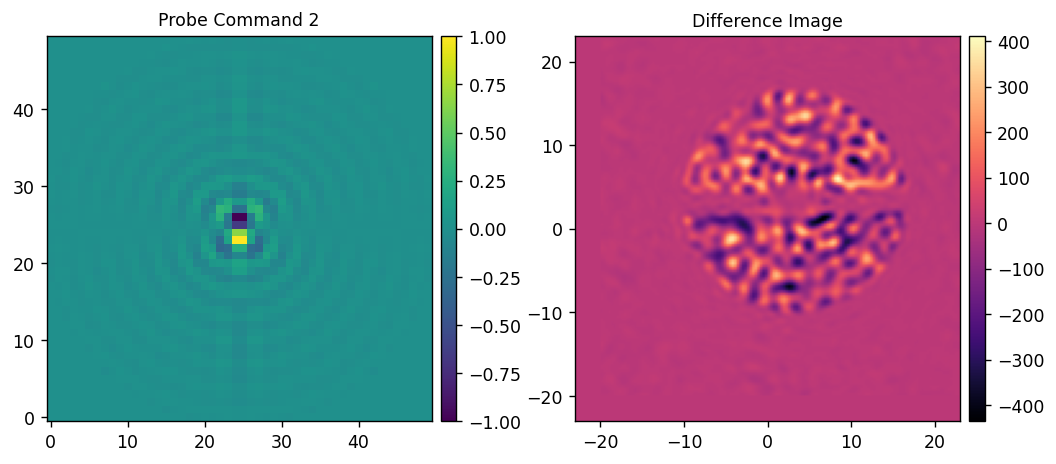

In [92]:
reload(iefc)
M.reset_dm()

diff_ims = iefc.take_measurement(
    M, 
    fourier_probes,
    2e-9,
    channel=3,
    plot=1,
)

Calibrating iEFC...
	Calibrated mode 2048/2048 in 125.165s
Calibration complete.


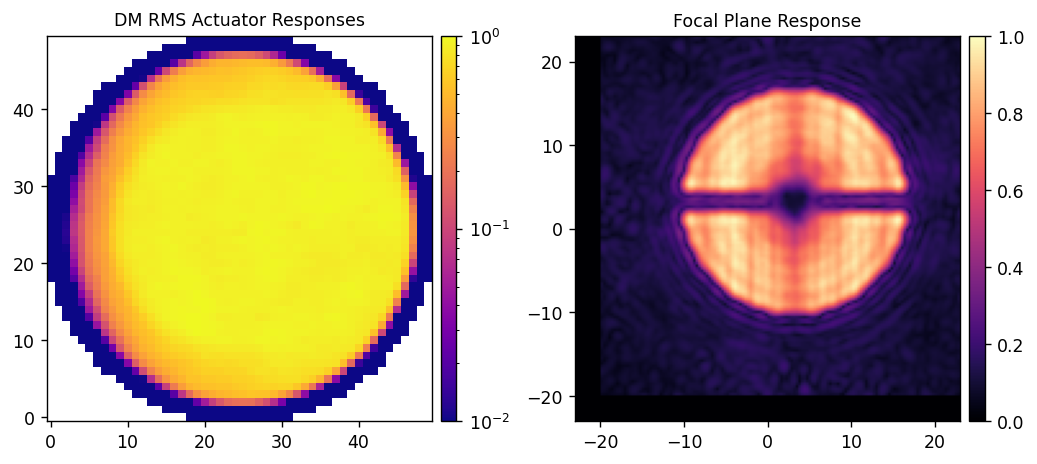

In [93]:
reload(iefc)
M.reset_dm()

probe_amp = 1e-9
calib_amp = 1e-9

response_matrix, response_cube = iefc.calibrate(
    M, 
    control_mask, 
    probe_amp, 
    fourier_probes, 
    calib_amp, 
    calib_modes[:], 
    plot_responses=True,
    channel=3,
)

In [94]:
reload(utils)
cm20 = utils.beta_reg(response_matrix, -2)
cm25 = utils.beta_reg(response_matrix, -2.5)
cm30 = utils.beta_reg(response_matrix, -3)
cm35 = utils.beta_reg(response_matrix, -3.5)
cm40 = utils.beta_reg(response_matrix, -4)
cm45 = utils.beta_reg(response_matrix, -4.5)
cm50 = utils.beta_reg(response_matrix, -5)

In [95]:
M.reset_dm()
data = {
    'images':[camsci_im0],
    'contrasts':[mean_contrast0],
    'commands':[],
    'del_commands':[],
    'pixelscale':M.camsci_pxscl_lamD,
    'control_mask':control_mask, 
    'probes':fourier_probes,
}

Running iEFC...
	Closed-loop iteration 1 / 3


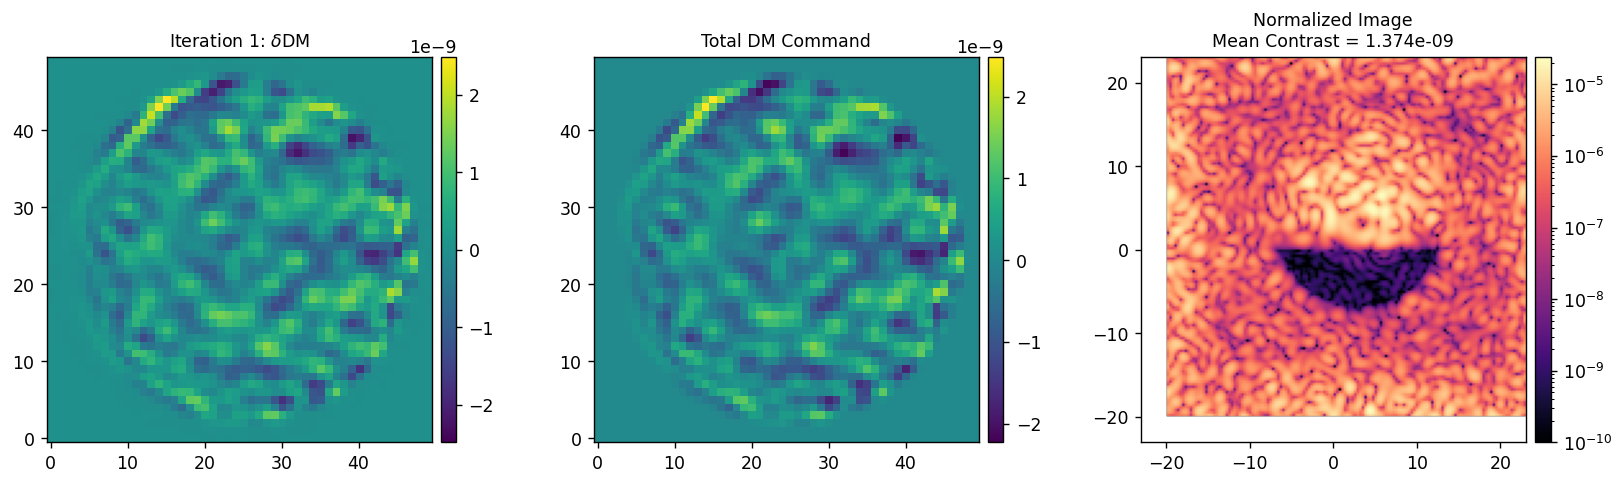

	Closed-loop iteration 2 / 3


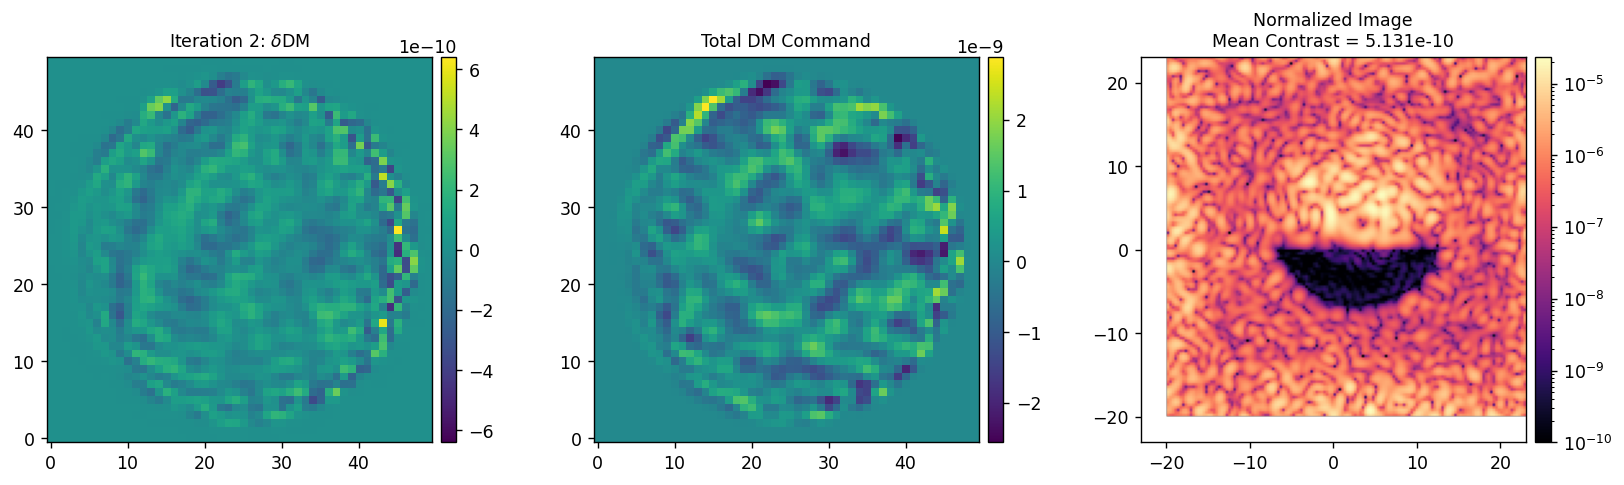

	Closed-loop iteration 3 / 3


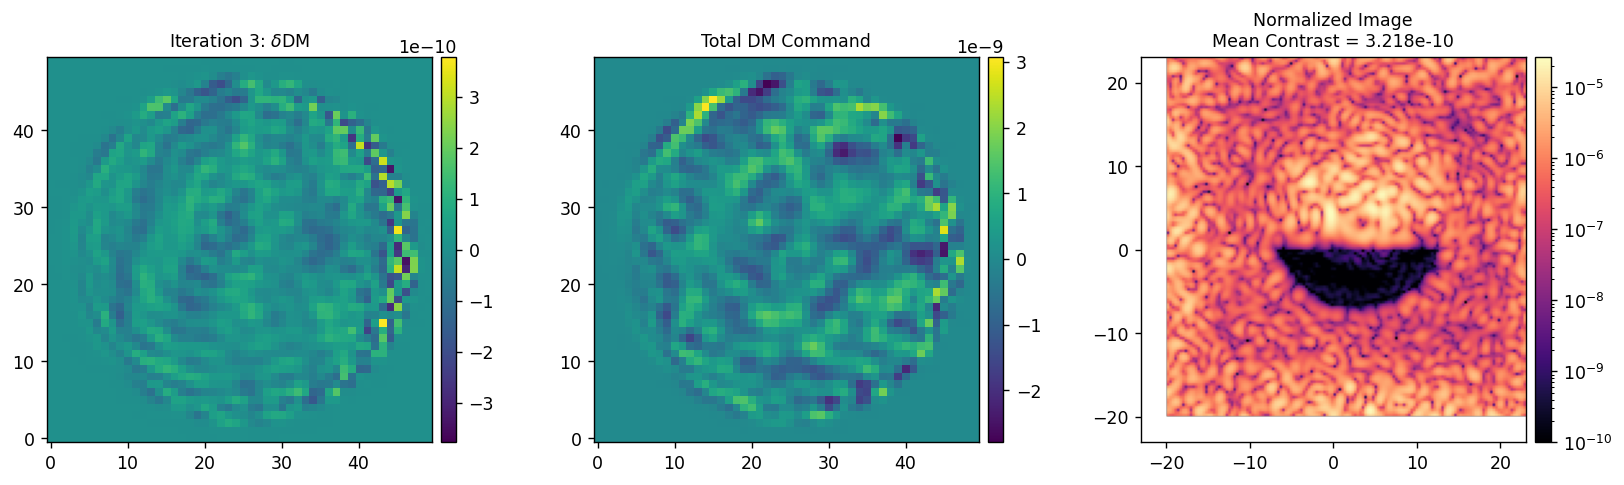

Closed loop for given control matrix completed in 1.404s.


In [96]:
reload(utils)
reload(iefc)

probe_amp = 2.5e-9
probe_amp = 1e-9
probe_amp = 0.25e-9

data = iefc.run(
    M,
    data,
    # cm20,
    cm25,
    # cm40,
    # cm45,
    # cm50,
    fourier_probes, 
    probe_amp, 
    calib_modes,
    control_mask,
    channel=3,
    num_iterations=3,
    gain=1, 
    leakage=0.0,
    plot_current=True,
    plot_all=True,
    plot_probes=False,
    vmin=1e-10,
)

In [97]:
utils.save_pickle('sim-data/example_iefc_data'+inwfefname[-6:], data)

Saved data to:  sim-data/example_iefc_data50.pkl


In [84]:
old_data = utils.load_pickle('sim-data/'+inwfefname)

In [85]:
from scoob_llowfsc import imshows
reload(imshows)

imshows.plot_data_with_ref(
    old_data,
    im1vmin=1e-9, im1vmax=1e-4,
    im2vmin=1e-11, im2vmax=1e-6,
    vmin=1e-11, vmax=1e-5,
    xticks=xp.arange(0,15+1,1),
)

KeyError: 'images'

In [29]:
from scoob_llowfsc import imshows
reload(imshows)
imshows.imshow3(
    old_data['images'][0],
    old_data['images'][-1],
    old_data['commands'][-1],
    f'Initial Coronagraphic Image\nMean Contrast = {old_data["contrasts"][0]:.2e}', 
    f'Nominal Dark Hole after iEFC\nMean Contrast = {old_data["contrasts"][-1]:.2e}',
    'iEFC Dark Hole Command',
    lognorm1=1,
    vmin1=1e-9, vmax1=1e-4,
    lognorm2=1,
    vmin2=1e-11, vmax2=1e-6,
    cmap3='viridis',
    pxscl1=old_data['pixelscale'],
    pxscl2=old_data['pixelscale'],
)

KeyError: 'images'

In [ ]:
from scoob_llowfsc import imshows
reload(imshows)

imshows.plot_howfsc(
    old_data,
    wfe_data['DM_FLAT'],
    im1vmin=1e-9, im1vmax=1e-4,
    im2vmin=1e-11, im2vmax=1e-6,
    vmin=1e-11, vmax=1e-5,
    xticks=np.arange(0,15+1,1),
    wspace=0.325, 
    hspace=0.05,
    plot_position=[0.725, 0.3, 0.4, 0.4],
    figsize=(15,10), 
    dpi=125,
)